In [4]:
# Manejo del sistema y rutas
import os
import sys
from pathlib import Path

# Procesamiento y manipulación de datos
import numpy as np
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Aprendizaje automático clásico (Scikit-Learn)
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning (TensorFlow y Keras independiente)
import tensorflow as tf
import keras
from keras import layers, models, optimizers, callbacks

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Dawer\.cache\kagglehub\datasets\uciml\autompg-dataset\versions\3


In [7]:
# Listar archivos en el path descargado
import os
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

# Encontrar el archivo de datos
archivo_datos = None
for archivo in archivos:
    if archivo.endswith('.csv') or archivo.endswith('.data'):
        archivo_datos = archivo
        break

# Cargar el dataset en DataFrame
if archivo_datos:
    archivo_ruta = os.path.join(path, archivo_datos)
    print(f"\nCargando: {archivo_ruta}")
    df = pd.read_csv(archivo_ruta)
    print(f"\nDataset cargado exitosamente!")
    print(f"Shape: {df.shape}")
    print(f"\nPrimeras filas:\n{df.head()}")
    print(f"\nColumnas:\n{df.columns.tolist()}")
else:
    print("No se encontró archivo de datos")

Archivos disponibles: ['auto-mpg.csv']

Cargando: C:\Users\Dawer\.cache\kagglehub\datasets\uciml\autompg-dataset\versions\3\auto-mpg.csv

Dataset cargado exitosamente!
Shape: (398, 9)

Primeras filas:
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  

Columnas:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'accel

In [12]:
#eliminar la columna 'car name' del DataFrame
df = df.drop(columns=['car name'], errors='ignore')
X_train = X_train.drop(columns=['car name'], errors='ignore') 

In [9]:
#validar celdas nulas
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [8]:
# Separar características (X) y variable objetivo (y)
X = df.drop('mpg', axis=1)  # Todas las características excepto mpg
y = df['mpg']               # Variable objetivo: mpg

# Dividir en 80% train y 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          # 20% para test
    random_state=42         # Para reproducibilidad
)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")
print(f"\nPorcentaje Train: {len(X_train) / len(X) * 100:.1f}%")
print(f"Porcentaje Test: {len(X_test) / len(X) * 100:.1f}%")

Shape de X_train: (318, 8)
Shape de X_test: (80, 8)
Shape de y_train: (318,)
Shape de y_test: (80,)

Porcentaje Train: 79.9%
Porcentaje Test: 20.1%


In [26]:
X=df.drop('mpg', axis=1)
y=df['mpg']

In [27]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [19]:
#convertir horsepower en float
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(3), int64(4), str(1)
memory usage: 25.0 KB


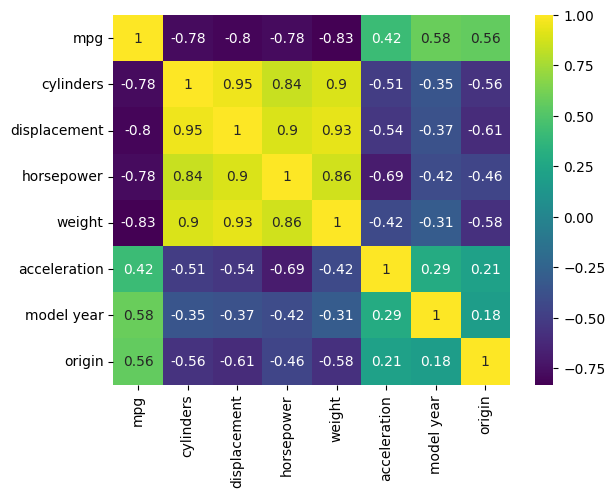

In [20]:
heatmap=sns.heatmap(df.corr(), annot=True, cmap='viridis')

In [22]:
#imputar en horpower en el nan la media de horsepower
df['horsepower'].fillna(df['horsepower'].mean())

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

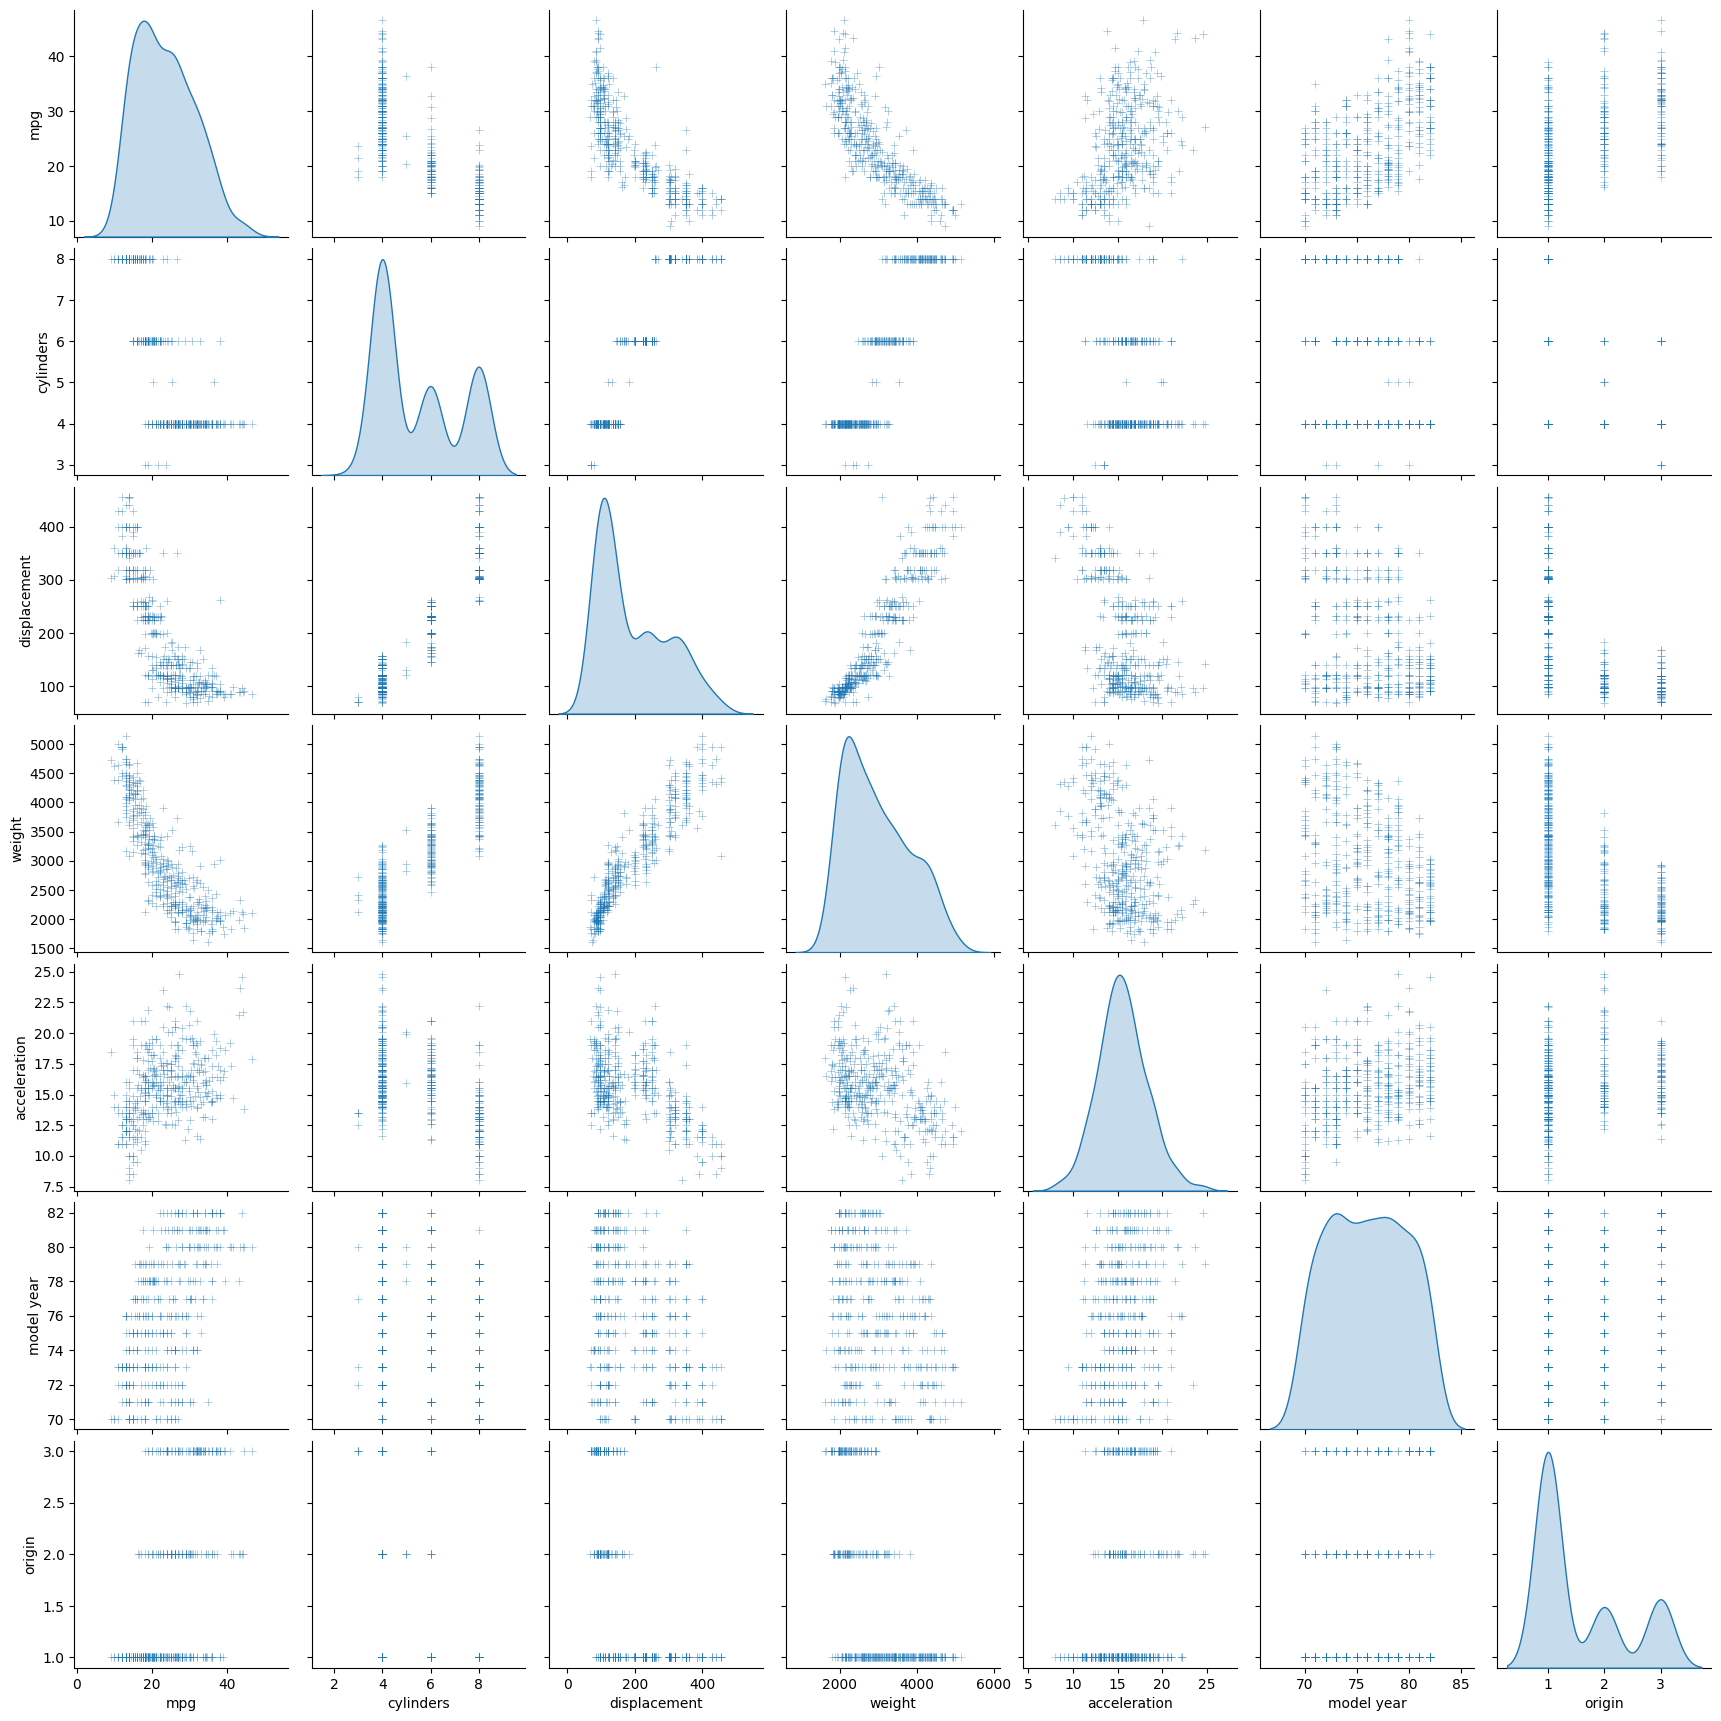

In [13]:
sns.pairplot(df, diag_kind='kde', markers='+', plot_kws={'alpha':0.5})

In [ ]:
#dividir

In [25]:
# Primero, limpiar el dataset reemplazando '?' con NaN
df_clean = df.replace('?', np.nan)

# Eliminar filas con valores faltantes
df_clean = df_clean.dropna()

print(f"Filas después de limpiar: {len(df_clean)}")
print(f"Valores faltantes por columna:\n{df_clean.isnull().sum()}")

# Volver a dividir el dataset limpio en 80/20
X_clean = df_clean.drop('mpg', axis=1)
y_clean = df_clean['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.2, 
    random_state=42
)

# Normalizar X_train y X_test usando StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDataset normalizado:")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"Media de X_train_scaled: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std de X_train_scaled: {X_train_scaled.std(axis=0).round(4)}")

Filas después de limpiar: 392
Valores faltantes por columna:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

Dataset normalizado:
X_train_scaled shape: (313, 7)
X_test_scaled shape: (79, 7)
Media de X_train_scaled: [ 0.  0. -0.  0.  0. -0.  0.]
Std de X_train_scaled: [1. 1. 1. 1. 1. 1. 1.]


In [28]:
X_train_scaled

array([[ 0.30486156,  0.28457757,  0.14142863, ...,  1.1217589 ,
         0.49452752, -0.68982474],
       [-0.87318372, -0.53588042, -0.32949862, ..., -0.22893966,
        -0.0572982 , -0.68982474],
       [ 0.30486156, -0.23665456, -0.19868549, ..., -0.37111846,
        -0.33321105, -0.68982474],
       ...,
       [-0.87318372, -0.4297035 , -0.51263699, ...,  0.73076722,
         0.49452752, -0.68982474],
       [-0.87318372, -0.94128319, -1.0358895 , ...,  1.83265289,
         1.32226608, -0.68982474],
       [ 1.48290683,  1.97375578,  1.18793363, ..., -0.54884195,
        -0.88503677, -0.68982474]], shape=(313, 7))

In [30]:
# Crear modelo secuencial
from keras.models import Sequential
from keras.layers import Input, Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Resumen del modelo
model.summary()

c:\Users\Dawer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.005), loss='mse', metrics=['mae'])

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history=model.fit(X_train_scaled, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 549.9905 - mae: 21.9463 - val_loss: 461.7775 - val_mae: 19.9955
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 326.9411 - mae: 15.7326 - val_loss: 220.3982 - val_mae: 12.7827
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 159.2426 - mae: 10.1142 - val_loss: 113.8907 - val_mae: 8.4155
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 108.7263 - mae: 8.1848 - val_loss: 97.9116 - val_mae: 7.8969
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 94.1329 - mae: 7.7968 - val_loss: 89.4537 - val_mae: 7.6326
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 85.5448 - mae: 7.5011 - val_loss: 85.6251 - val_mae: 7.4738
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 80.5570 - mae: 7.3585 - val_loss: 80.0352 - val_mae: 7.4041
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 76.9434 - mae: 7.2281 - val_loss: 86.8102 - val_mae: 7.5274
Epoch 9/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

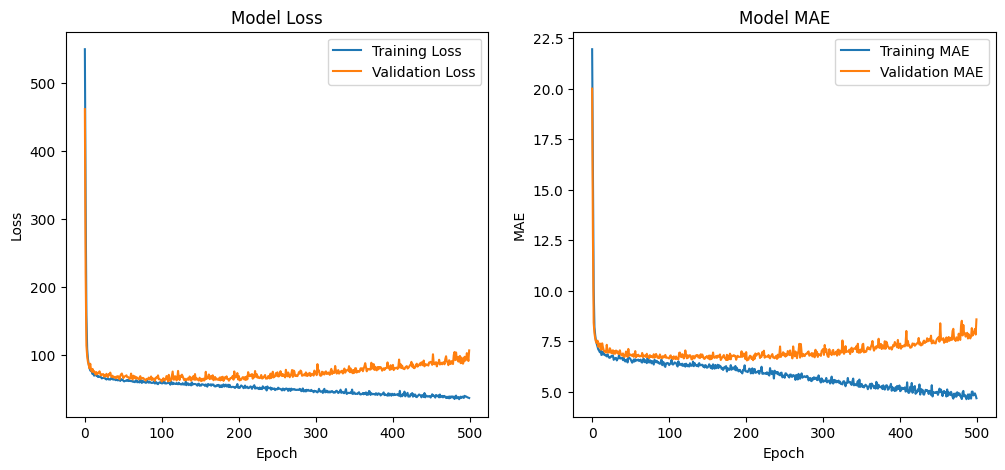

In [34]:
#graficar la historia de entrenamiento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [41]:
#guardar el modelo en .keras
model.save('modeloGasolina.keras')

In [36]:
#predecir con los datos de X_test_scaled
y_pred = model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [40]:
# Calcular el error medio cuadrático (MSE) y error medio absoluto (MAE)
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Realizar predicciones en el conjunto de prueba
y_pred_test = model.predict(X_test_scaled, verbose=0)

# Convertir y_test a numpy array para que coincida con y_pred_test
y_test_values = y_test.values if hasattr(y_test, 'values') else y_test

# Asegurar que ambos tienen el mismo tamaño (usar solo las primeras 79 muestras)
y_test_values = y_test_values[:len(y_pred_test)]

# Calcular MSE y MAE
mse = mean_squared_error(y_test_values, y_pred_test)
mae = mean_absolute_error(y_test_values, y_pred_test)

# Calcular RMSE (raíz del error cuadrático medio)
rmse = np.sqrt(mse)

# Mostrar resultados
print("=" * 50)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("=" * 50)
print(f"Error Medio Cuadrático (MSE):      {mse:.4f}")
print(f"Raíz del Error Cuadrático (RMSE):  {rmse:.4f}")
print(f"Error Medio Absoluto (MAE):        {mae:.4f}")
print("=" * 50)

MÉTRICAS DE EVALUACIÓN DEL MODELO
Error Medio Cuadrático (MSE):      103.2983
Raíz del Error Cuadrático (RMSE):  10.1636
Error Medio Absoluto (MAE):        8.0287
